In [3]:
"""
Phase-Aware Injury Detection Labeling
======================================
Detects the exercise phase from joint angles, then applies biomechanical
thresholds ONLY at key/steady phases. Transition images are labeled
"transition" and excluded from injury classification.
 
Supported exercises:
    pull_up, shoulder_press, squat, t_bar_row, leg_extension
 
Input CSV columns expected:
    image_path, folder_name, shoulder_angles, elbow_angles,
    hip_angles, knee_angles, front_facing_boolean, body_angles
 
Output CSV adds:
    exercise_key, phase, phase_is_steady, label,
    violated_rules, violated_sources,
    flag_shoulder, flag_elbow, flag_hip, flag_knee
 
Usage:
    python phase_aware_labeling.py --input features.csv --output phase_labeled.csv
    python phase_aware_labeling.py --input features.csv --output phase_labeled.csv --summary
    python phase_aware_labeling.py --input features.csv --print_phases
 
Requirements:
    pip install pandas numpy
"""
 
import pandas as pd
import numpy as np
import argparse
import os
import sys
from collections import Counter
 
 
# =============================================================================
# PHASE DEFINITIONS
# =============================================================================
# Each exercise defines phases as a list of dicts, evaluated top-to-bottom.
# The FIRST phase whose condition evaluates True is assigned.
#
# Each phase dict:
#   name         : human-readable phase label
#   is_steady    : True = apply injury thresholds here
#                  False = transition, skip thresholding
#   condition    : lambda(row) → bool  (uses angle columns directly)
#   description  : what this phase represents biomechanically
#
# Phase detection uses the PRIMARY driver joint for each exercise:
#   pull_up        → elbow_angle (ROM driver)
#   shoulder_press → elbow_angle (ROM driver)
#   squat          → knee_angle  (ROM driver)
#   t_bar_row      → elbow_angle (ROM driver)
#   leg_extension  → knee_angle  (ROM driver)
# =============================================================================
 
PHASE_DEFINITIONS = {
 
    # -------------------------------------------------------------------------
    # PULL UP
    # -------------------------------------------------------------------------
    # Dead hang : elbow fully extended ≥ 155°  → check shoulder impingement
    # Top       : elbow deeply flexed  ≤ 75°   → check shoulder & elbow range
    # Transition: everything between             → skip
    #
    # Rationale: at dead hang the shoulder is in full overhead load bearing
    # position — impingement risk is highest. At top, elbow flexion range and
    # shoulder position confirm chin-over-bar completion without hyperflexion.
    # Sources: Youdas et al. (2010); Ronai & Scibek (2014)
    # -------------------------------------------------------------------------
    "pull up": [
        {
            "name": "dead_hang",
            "is_steady": True,
            "condition": lambda r: _get(r, "elbow_angles") >= 155,
            "description": "Arms fully extended, hanging position",
            "thresholds": {
                "elbow_angles": {
                    "correct_range": (155, 185),
                    "injury_description": "Elbow not fully extended in dead hang — incomplete starting position",
                    "source": "Youdas et al. (2010) J. Strength Cond. Res. 24(12):3404–3414"
                },
                "hip_angles": None,
                "knee_angles": None,
            }
        },
        {
            "name": "top_position",
            "is_steady": True,
            "condition": lambda r: _get(r, "elbow_angles") <= 75,
            "description": "Chin above bar, maximum contraction",
            "thresholds": {
                "elbow_angles": {
                    "correct_range": (40, 75),
                    "injury_description": "Elbow not sufficiently flexed at top — incomplete range of motion",
                    "source": "Youdas et al. (2010) J. Strength Cond. Res. 24(12):3404–3414"
                },
                "hip_angles": None,
                "knee_angles": None,
            }
        },
        {
            "name": "transition",
            "is_steady": False,
            "condition": lambda r: True,
            "description": "Mid-pull transition — not evaluated",
            "thresholds": {}
        },
    ],
 
    # -------------------------------------------------------------------------
    # SHOULDER PRESS
    # -------------------------------------------------------------------------
    # Rack position : elbow ≤ 100° AND shoulder ≤ 110°  → check starting setup
    # Lockout       : elbow ≥ 155°                       → check hyperextension
    # Transition    : everything between                  → skip
    #
    # Rationale: the rack position determines bar path and shoulder health at
    # the most loaded point. Lockout checks for hyperextension and impingement
    # at full overhead extension.
    # Sources: Kolber et al. (2014); Dillman et al. (1994)
    # -------------------------------------------------------------------------
    "shoulder press": [
        {
            "name": "rack_position",
            "is_steady": True,
            "condition": lambda r: (
                _get(r, "elbow_angles") <= 100 and
                _get(r, "shoulder_angles") <= 110
            ),
            "description": "Bar at shoulder height, start/end of press",
            "thresholds": {
                "elbow_angles": {
                    "correct_range": (75, 100),
                    "injury_description": "Elbow angle at rack indicates unsafe bar path",
                    "source": "Dillman et al. (1994) J. Sport Rehabil. 3(3):228–238"
                },
                "hip_angles": None,
                "knee_angles": None,
            }
        },
        {
            "name": "lockout",
            "is_steady": True,
            "condition": lambda r: _get(r, "elbow_angles") >= 155,
            "description": "Arms fully extended overhead",
            "thresholds": {
                "elbow_angles": {
                    "correct_range": (155, 185),
                    "injury_description": "Elbow hyperextension at lockout — joint stress risk",
                    "source": "Kolber et al. (2014) J. Strength Cond. Res. 28(5):1213–1217"
                },
                "hip_angles": None,
                "knee_angles": None,
            }
        },
        {
            "name": "transition",
            "is_steady": False,
            "condition": lambda r: True,
            "description": "Mid-press transition — not evaluated",
            "thresholds": {}
        },
    ],
 
    # -------------------------------------------------------------------------
    # SQUAT
    # -------------------------------------------------------------------------
    # Standing  : knee ≥ 155°            → check lockout / hyperextension
    # Bottom    : knee ≤ 100°            → check depth, butt wink, knee cave
    # Transition: everything between      → skip
    #
    # Rationale: standing lockout reveals hyperextension or incomplete lockout.
    # Bottom position is where butt wink (lumbar flexion) and knee-over-toe
    # issues are most pronounced and most injurious.
    # Sources: Schoenfeld (2010); Escamilla (2001); McGill (2015)
    # -------------------------------------------------------------------------
    "squat": [
        {
            "name": "standing",
            "is_steady": True,
            "condition": lambda r: _get(r, "knee_angles") >= 155,
            "description": "Standing lockout position",
            "thresholds": {
                "elbow_angles": None,
                "hip_angles": {
                    "correct_range": (155, 185),
                    "injury_description": "Hips not fully extended at lockout — incomplete rep",
                    "source": "Schoenfeld (2010) J. Strength Cond. Res. 24(12):3497–3506"
                },
                "knee_angles": {
                    "correct_range": (155, 185),
                    "injury_description": "Knee hyperextension at lockout — posterior capsule stress",
                    "source": "Escamilla (2001) Med. Sci. Sports Exerc. 33(1):127–141"
                },
            }
        },
        {
            "name": "bottom_position",
            "is_steady": True,
            "condition": lambda r: _get(r, "knee_angles") <= 100,
            "description": "Bottom of squat, maximum depth",
            "thresholds": {
                "elbow_angles": None,
                "hip_angles": {
                    "correct_range": (55, 105),
                    "injury_description": "Butt wink detected — lumbar flexion injury risk at depth",
                    "source": "Schoenfeld (2010) J. Strength Cond. Res. 24(12):3497–3506; McGill (2015)"
                },
                "knee_angles": {
                    "correct_range": (55, 100),
                    "injury_description": "Knee angle at depth outside safe range — patellar compressive stress",
                    "source": "Escamilla (2001) Med. Sci. Sports Exerc. 33(1):127–141"
                },
            }
        },
        {
            "name": "transition",
            "is_steady": False,
            "condition": lambda r: True,
            "description": "Descent / ascent transition — not evaluated",
            "thresholds": {}
        },
    ],
 
    # -------------------------------------------------------------------------
    # T-BAR ROW
    # -------------------------------------------------------------------------
    # Start (arms extended) : elbow ≥ 150°   → check hip hinge setup
    # Full row (contracted) : elbow ≤ 80°    → check shoulder & elbow at peak
    # Transition            : everything between → skip
    #
    # Rationale: at the start position, hip hinge angle determines lumbar load
    # throughout the entire set. At full contraction, shoulder retraction and
    # elbow position reveal impingement and bicep tendon stress risks.
    # Sources: Fenwick et al. (2009); McGill (2015); Signorile et al. (2002)
    # -------------------------------------------------------------------------
    "t bar row": [
        {
            "name": "start_position",
            "is_steady": True,
            "condition": lambda r: _get(r, "elbow_angles") >= 150,
            "description": "Arms extended, hip hinge setup",
            "thresholds": {
                "elbow_angles": {
                    "correct_range": (150, 185),
                    "injury_description": "Elbow not fully extended at row start — incomplete ROM",
                    "source": "Fenwick et al. (2009) J. Strength Cond. Res. 23(5):1408–1417"
                },
                "hip_angles": {
                    "correct_range": (80, 145),
                    "injury_description": "Hip hinge angle outside safe range — elevated L4/L5 spinal load",
                    "source": "Fenwick et al. (2009) ibid.; McGill (2015) Back Mechanic"
                },
                "knee_angles": None,
            }
        },
        {
            "name": "full_contraction",
            "is_steady": True,
            "condition": lambda r: _get(r, "elbow_angles") <= 80,
            "description": "Bar at chest, maximum contraction",
            "thresholds": {
                "elbow_angles": {
                    "correct_range": (50, 80),
                    "injury_description": "Elbow over-flexed at contraction — bicep tendon stress",
                    "source": "Fenwick et al. (2009) J. Strength Cond. Res. 23(5):1408–1417"
                },
                "hip_angles": {
                    "correct_range": (80, 145),
                    "injury_description": "Hip angle collapsed during row — lumbar stress risk",
                    "source": "Fenwick et al. (2009) ibid.; McGill (2015) Back Mechanic"
                },
                "knee_angles": None,
            }
        },
        {
            "name": "transition",
            "is_steady": False,
            "condition": lambda r: True,
            "description": "Mid-row transition — not evaluated",
            "thresholds": {}
        },
    ],
 
    # -------------------------------------------------------------------------
    # LEG EXTENSION
    # -------------------------------------------------------------------------
    # Start (bent)  : knee < 110°   → check starting flexion (compression risk)
    # Extended      : knee ≥ 110°   → check hyperextension
    #
    # Note: leg extension has no true "transition" — the movement is simple
    # enough that both phases are evaluated. The risk profile differs between
    # phases: compressive forces peak at high flexion, hyperextension risk
    # peaks at near-full extension.
    # Sources: Witvrouw et al. (2004); Escamilla et al. (1998); Steinkamp et al. (1993)
    # -------------------------------------------------------------------------
    "leg extension": [
        {
            "name": "start_bent",
            "is_steady": True,
            "condition": lambda r: _get(r, "knee_angles") < 110,
            "description": "Starting position, knee flexed",
            "thresholds": {
                "shoulder_angles": None,
                "elbow_angles": None,
                "hip_angles": None,
                "knee_angles": {
                    "correct_range": (70, 109),
                    "injury_description": "Knee over-flexed at start — patellofemoral compressive force risk",
                    "source": "Steinkamp et al. (1993) Am. J. Sports Med. 21(3):438–444"
                },
            }
        },
        {
            "name": "extended",
            "is_steady": True,
            "condition": lambda r: True,
            "description": "Leg extended position",
            "thresholds": {
                "shoulder_angles": None,
                "elbow_angles": None,
                "hip_angles": None,
                "knee_angles": {
                    "correct_range": (110, 175),
                    "injury_description": "Knee hyperextension on leg extension machine — posterior capsule and ACL stress",
                    "source": "Witvrouw et al. (2004) Am. J. Sports Med. 32(5):1122–1130; "
                              "Escamilla et al. (1998) Med. Sci. Sports Exerc. 30(4):556–569"
                },
            }
        },
    ],
}
 
# Angles actually evaluated for injury thresholds.
# shoulder_angles is EXCLUDED because in this notebook it is computed as
# the angle at the shoulder between hip→shoulder→elbow vectors, which is a
# torso-lean proxy — not the arm-elevation angle that literature thresholds
# assume. Applying literature values to this geometric definition produces
# systematic false positives across all exercises.
ANGLE_COLUMNS = ["elbow_angles", "hip_angles", "knee_angles"]
 
# Images with |body_angles| above this threshold are considered too rotated
# for reliable threshold evaluation and are labeled "rotated_view".
# 30° is chosen because beyond this the 2-D joint projections diverge
# significantly from the frontal-plane assumptions in the threshold literature.
ROTATION_THRESHOLD_DEG = 30.0
 
FOLDER_NAME_MAP = {
    "pull up": "pull up", "pullup": "pull up", "pull_up": "pull up",
    "shoulder press": "shoulder press", "shoulderpress": "shoulder press", "shoulder_press": "shoulder press",
    "squat": "squat", "squats": "squat",
    "t bar row": "t bar row", "tbarrow": "t bar row", "t_bar_row": "t bar row",
    "leg extension": "leg extension", "legextension": "leg extension", "leg_extension": "leg extension",
}
 
 
# =============================================================================
# HELPERS
# =============================================================================
 
def _get(row, col):
    """Safely get a float from a row dict. Returns NaN if missing/invalid."""
    val = row.get(col, np.nan)
    try:
        return float(val)
    except (TypeError, ValueError):
        return np.nan
 
 
def resolve_exercise(folder_name_raw):
    return FOLDER_NAME_MAP.get(str(folder_name_raw).strip().lower())
 
 
def is_too_rotated(row):
    """
    Return True if the body is rotated beyond ROTATION_THRESHOLD_DEG.
    Uses body_angles (arctan2 of shoulder Z-depth difference) from your notebook.
    Also respects front_facing_boolean when body_angles is unavailable.
    """
    body_angle = _get(row, "body_angles")
 
    # Primary check: use the continuous body_angles value
    if not np.isnan(body_angle):
        return abs(body_angle) > ROTATION_THRESHOLD_DEG
 
    # Fallback: use the boolean flag your notebook computed
    front_facing_raw = row.get("front_facing_boolean", None)
    if front_facing_raw is not None:
        val = str(front_facing_raw).strip().lower()
        if val in ("false", "0"):
            return True   # explicitly not front-facing → treat as rotated
        if val in ("true", "1"):
            return False  # explicitly front-facing → not rotated
 
    # Cannot determine rotation — allow through (conservative)
    return False
 
 
# =============================================================================
# PHASE DETECTION
# =============================================================================
 
def detect_phase(row, exercise_key):
    """
    Evaluate phase conditions top-to-bottom and return the first match.
 
    Returns:
        phase_name  (str)
        is_steady   (bool)
        description (str)
        thresholds  (dict)
    """
    phases = PHASE_DEFINITIONS.get(exercise_key, [])
    row_dict = row.to_dict() if hasattr(row, "to_dict") else row
 
    for phase in phases:
        try:
            if phase["condition"](row_dict):
                return (
                    phase["name"],
                    phase["is_steady"],
                    phase["description"],
                    phase["thresholds"]
                )
        except Exception:
            continue
 
    return "unknown", False, "Could not determine phase", {}
 
 
# =============================================================================
# THRESHOLD APPLICATION
# =============================================================================
 
def apply_thresholds(row, thresholds):
    """
    Apply phase-specific thresholds to a row.
 
    Returns:
        label    (str): "correct" or "injury_prone"
        violated (list[str])
        sources  (list[str])
        flags    (dict)
    """
    violated = []
    sources = []
    flags = {}
    row_dict = row.to_dict() if hasattr(row, "to_dict") else row
 
    for col in ANGLE_COLUMNS:
        rule = thresholds.get(col)
 
        if rule is None:
            flags[col] = "not_applicable"
            continue
 
        value = _get(row_dict, col)
 
        if np.isnan(value):
            flags[col] = "missing"
            continue
 
        lo, hi = rule["correct_range"]
 
        if value < lo or value > hi:
            violated.append(
                f"{col}={value:.1f}° outside [{lo}°–{hi}°]: {rule['injury_description']}"
            )
            sources.append(rule["source"])
            flags[col] = "injury_prone"
        else:
            flags[col] = "correct"
 
    label = "injury_prone" if violated else "correct"
    return label, violated, sources, flags
 
 
# =============================================================================
# MAIN LABELING
# =============================================================================
 
def label_dataframe(df):
    """
    Full pipeline: phase detection → threshold application → label assignment.
 
    Rows at transition phases get label = "transition" and are excluded
    from injury classification. Only steady-phase rows get "correct" or
    "injury_prone".
    """
    records = []
 
    for _, row in df.iterrows():
        ex_key = resolve_exercise(row.get("folder_name", ""))
 
        base = {
            "exercise_key":    None,
            "phase":           None,
            "phase_is_steady": False,
            "phase_description": None,
            "label":           "skipped",
            "violated_rules":  "",
            "violated_sources": "",
            "flag_shoulder":   "skipped",
            "flag_elbow":      "skipped",
            "flag_hip":        "skipped",
            "flag_knee":       "skipped",
        }
 
        if ex_key is None:
            records.append(base)
            continue
 
        phase_name, is_steady, phase_desc, thresholds = detect_phase(row, ex_key)
 
        base["exercise_key"]      = ex_key
        base["phase"]             = phase_name
        base["phase_is_steady"]   = is_steady
        base["phase_description"] = phase_desc
 
        # --- Rotation filter ---
        # Skip threshold evaluation if body is too rotated.
        # 2-D joint angle projections are unreliable beyond ROTATION_THRESHOLD_DEG.
        if is_steady and is_too_rotated(row):
            base["label"] = "rotated_view"
            records.append(base)
            continue
 
        if not is_steady:
            base["label"] = "transition"
            records.append(base)
            continue
 
        label, violated, sources, flags = apply_thresholds(row, thresholds)
 
        base["label"]             = label
        base["violated_rules"]    = " | ".join(violated) if violated else ""
        base["violated_sources"]  = " | ".join(set(sources)) if sources else ""
        base["flag_shoulder"]     = flags.get("shoulder_angles", "not_applicable")
        base["flag_elbow"]        = flags.get("elbow_angles",    "not_applicable")
        base["flag_hip"]          = flags.get("hip_angles",      "not_applicable")
        base["flag_knee"]         = flags.get("knee_angles",     "not_applicable")
 
        records.append(base)
 
    result_df = pd.DataFrame(records)
    return pd.concat([df.reset_index(drop=True), result_df.reset_index(drop=True)], axis=1)
 
 
# =============================================================================
# SUMMARY
# =============================================================================
 
def print_summary(df):
    print(f"\n{'='*60}")
    print(f"  PHASE-AWARE LABELING SUMMARY")
    print(f"{'='*60}")
    print(f"  Total rows       : {len(df)}")
 
    skipped    = df[df["label"] == "skipped"]
    transition = df[df["label"] == "transition"]
    rotated    = df[df["label"] == "rotated_view"]
    labeled    = df[df["label"].isin(["correct", "injury_prone"])]
 
    print(f"  Skipped          : {len(skipped)}  (unsupported exercise)")
    print(f"  Transition       : {len(transition)}  (mid-rep, not evaluated)")
    print(f"  Rotated view     : {len(rotated)}  (|body_angle| > {ROTATION_THRESHOLD_DEG}°, excluded)")
    print(f"  Steady-phase     : {len(labeled)}  (evaluated for injury)")
 
    if len(labeled) == 0:
        print("  No rows were labeled at steady phases.")
        return
 
    print(f"\n  Steady-phase label distribution:")
    for lbl, cnt in labeled["label"].value_counts().items():
        pct = cnt / len(labeled) * 100
        bar = "█" * int(pct / 2)
        print(f"    {lbl:15s}: {cnt:4d} ({pct:5.1f}%)  {bar}")
 
    print(f"\n  Per-exercise breakdown:")
    for ex in sorted(labeled["exercise_key"].dropna().unique()):
        sub = labeled[labeled["exercise_key"] == ex]
        print(f"\n    [{ex.upper()}]  steady-phase total = {len(sub)}")
 
        for phase in sub["phase"].unique():
            ph = sub[sub["phase"] == phase]
            correct = (ph["label"] == "correct").sum()
            injury  = (ph["label"] == "injury_prone").sum()
            total   = len(ph)
            print(f"      phase: {phase:20s}  total={total:4d}  "
                  f"correct={correct:4d} ({correct/total*100:.0f}%)  "
                  f"injury_prone={injury:4d} ({injury/total*100:.0f}%)")
 
        # Most violated rules across all phases of this exercise
        viol = sub[sub["label"] == "injury_prone"]["violated_rules"]
        if len(viol) > 0:
            all_parts = []
            for v in viol.dropna():
                for part in v.split(" | "):
                    col = part.split("=")[0].strip()
                    all_parts.append(col)
            counts = Counter(all_parts)
            print(f"      most violated angles:")
            for rule, n in counts.most_common(3):
                print(f"        - {rule}: {n} images")
 
    # Transition breakdown per exercise
    print(f"\n  Transition (excluded) breakdown:")
    trans_supported = transition[transition["exercise_key"].notna()]
    if len(trans_supported) > 0:
        for ex in sorted(trans_supported["exercise_key"].dropna().unique()):
            n = (trans_supported["exercise_key"] == ex).sum()
            print(f"    {ex:20s}: {n} images excluded")
 
    print(f"\n{'='*60}\n")
 
 
def print_phases():
    print(f"\n{'='*70}")
    print(f"  PHASE DEFINITIONS")
    print(f"{'='*70}")
    for ex, phases in PHASE_DEFINITIONS.items():
        print(f"\n  [{ex.upper()}]")
        for p in phases:
            steady_tag = "STEADY — thresholds applied" if p["is_steady"] else "TRANSITION — skipped"
            print(f"    phase: {p['name']:25s} [{steady_tag}]")
            print(f"           {p['description']}")
            if p["is_steady"] and p["thresholds"]:
                for col, rule in p["thresholds"].items():
                    if rule:
                        lo, hi = rule["correct_range"]
                        print(f"           {col:22s}: {lo}°–{hi}°")
    print(f"\n{'='*70}\n")

In [9]:
train_df = pd.read_csv("../data/train_data_with_extracted_features-new.csv")

In [10]:
labeled = label_dataframe(train_df)
print_summary(labeled)
labeled.head()


  PHASE-AWARE LABELING SUMMARY
  Total rows       : 5510
  Skipped          : 3452  (unsupported exercise)
  Transition       : 532  (mid-rep, not evaluated)
  Rotated view     : 1159  (|body_angle| > 30.0°, excluded)
  Steady-phase     : 367  (evaluated for injury)

  Steady-phase label distribution:
    correct        :  324 ( 88.3%)  ████████████████████████████████████████████
    injury_prone   :   43 ( 11.7%)  █████

  Per-exercise breakdown:

    [LEG EXTENSION]  steady-phase total = 238
      phase: extended              total= 238  correct= 233 (98%)  injury_prone=   5 (2%)
      most violated angles:
        - knee_angles: 5 images

    [PULL UP]  steady-phase total = 79
      phase: top_position          total=  30  correct=   4 (13%)  injury_prone=  26 (87%)
      phase: dead_hang             total=  49  correct=  49 (100%)  injury_prone=   0 (0%)
      most violated angles:
        - elbow_angles: 26 images

    [SHOULDER PRESS]  steady-phase total = 16
      phase: locko

,image_path,folder_name,shoulder_angles,elbow_angles,hip_angles,knee_angles,front_facing_boolean,body_angles,exercise_key,phase,phase_is_steady,phase_description,label,violated_rules,violated_sources,flag_shoulder,flag_elbow,flag_hip,flag_knee
0,pull up/pull up_700241.jpg,pull up,136.52410413422396,124.66651815921597,Not Found,Not Found,True,0.3360388217404142,pull up,transition,False,Mid-pull transition — not evaluated,transition,,,skipped,skipped,skipped,skipped
1,pull up/pull up_300081.jpg,pull up,174.54402395584725,177.39085095557985,177.92281653750007,174.91258717837394,False,-86.89127123986803,pull up,dead_hang,True,"Arms fully extended, hanging position",rotated_view,,,skipped,skipped,skipped,skipped
2,pull up/pull up_600291.jpg,pull up,161.51367788319382,147.72734259465963,40.964084857812566,144.09474164150413,True,-7.026523158139829,pull up,transition,False,Mid-pull transition — not evaluated,transition,,,skipped,skipped,skipped,skipped
3,pull up/pull up_300221.jpg,pull up,170.93892722139364,173.21629793507236,169.02042872863143,176.26752395909114,False,-105.62565100467461,pull up,dead_hang,True,"Arms fully extended, hanging position",rotated_view,,,skipped,skipped,skipped,skipped
4,pull up/pull up_1100001.jpg,pull up,173.23030328345322,178.66475054362854,174.34377474653814,177.8571240271482,False,118.90876862101534,pull up,dead_hang,True,"Arms fully extended, hanging position",rotated_view,,,skipped,skipped,skipped,skipped


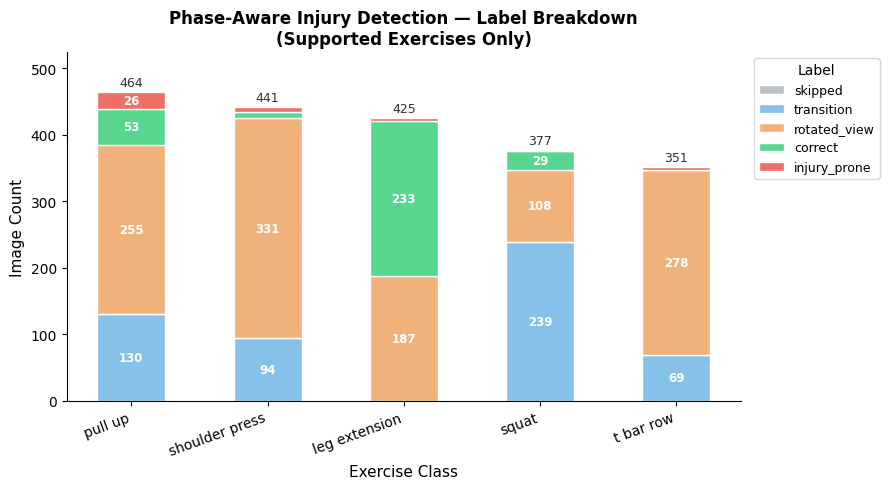

In [7]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

label_order = ['skipped', 'transition', 'rotated_view', 'correct', 'injury_prone']
colours     = ['#bdc3c7',  '#85c1e9',   '#f0b27a',      '#58d68d',  '#ec7063']

pivot = (
    labeled
    .groupby(['folder_name', 'label'])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=label_order, fill_value=0)
)

# ── Filter to injury-detection exercises only ─────────────────────────────────
injury_exercises = ['pull up', 'shoulder press', 'squat', 't bar row', 'leg extension']
pivot = pivot.loc[pivot.index.isin(injury_exercises)]

# Sort by total count descending
pivot = pivot.loc[pivot.sum(axis=1).sort_values(ascending=False).index]

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))

bottoms = np.zeros(len(pivot))
for col, colour in zip(label_order, colours):
    values = pivot[col].values
    bars = ax.bar(pivot.index, values, bottom=bottoms,
                  color=colour, label=col, edgecolor='white', width=0.5)

    for bar, val, bot in zip(bars, values, bottoms):
        if val > 10:
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bot + val / 2,
                    str(val), ha='center', va='center',
                    fontsize=8.5, color='white', fontweight='bold')
    bottoms += values

for i, total in enumerate(pivot.sum(axis=1)):
    ax.text(i, total + 5, str(total),
            ha='center', va='bottom', fontsize=9, color='#333333')

ax.set_xlabel('Exercise Class', fontsize=11)
ax.set_ylabel('Image Count', fontsize=11)
ax.set_title('Phase-Aware Injury Detection — Label Breakdown\n(Supported Exercises Only)',
             fontsize=12, fontweight='bold')
ax.set_xticks(range(len(pivot)))
ax.set_xticklabels(pivot.index, rotation=20, ha='right', fontsize=10)
ax.legend(title='Label', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
ax.spines[['top', 'right']].set_visible(False)
ax.set_ylim(0, pivot.sum(axis=1).max() + 60)

plt.tight_layout()
plt.savefig('injury_label_breakdown.png', dpi=150, bbox_inches='tight')
plt.show()



In [4]:
def get_injury_prone(df, exercise, phase=None):
    mask = (
        (df["exercise_key"] == exercise) &
        (df["label"] == "injury_prone")
    )
    if phase:
        mask &= (df["phase"] == phase)
    
    return df[mask].reset_index(drop=True)

In [8]:
squat_injury = get_injury_prone(labeled, "t bar row")
squat_injury

,image_path,folder_name,shoulder_angles,elbow_angles,hip_angles,knee_angles,front_facing_boolean,body_angles,exercise_key,phase,phase_is_steady,phase_description,label,violated_rules,violated_sources,flag_shoulder,flag_elbow,flag_hip,flag_knee
0,t bar row/t bar row_2100241.jpg,t bar row,4.951031845184434,174.04046816625058,166.66244592169912,Not Found,True,0.31834232241055815,t bar row,start_position,True,"Arms extended, hip hinge setup",injury_prone,hip_angles=166.7° outside [80°–145°]: Hip hing...,Fenwick et al. (2009) ibid.; McGill (2015) Bac...,not_applicable,correct,injury_prone,not_applicable
1,t bar row/t bar row_2000171.jpg,t bar row,21.0942935258263,170.3489879591153,178.93419841349404,179.006822724179,True,-27.260227178173565,t bar row,start_position,True,"Arms extended, hip hinge setup",injury_prone,hip_angles=178.9° outside [80°–145°]: Hip hing...,Fenwick et al. (2009) ibid.; McGill (2015) Bac...,not_applicable,correct,injury_prone,not_applicable
2,t bar row/t bar row_2100261.jpg,t bar row,8.812328769584179,166.52855297383928,170.61012158095593,Not Found,True,-0.7552141716973892,t bar row,start_position,True,"Arms extended, hip hinge setup",injury_prone,hip_angles=170.6° outside [80°–145°]: Hip hing...,Fenwick et al. (2009) ibid.; McGill (2015) Bac...,not_applicable,correct,injury_prone,not_applicable
3,t bar row/t bar row_1800371.jpg,t bar row,8.591395479431934,170.28453046714966,165.4401741635752,Not Found,True,-1.8811037993600621,t bar row,start_position,True,"Arms extended, hip hinge setup",injury_prone,hip_angles=165.4° outside [80°–145°]: Hip hing...,Fenwick et al. (2009) ibid.; McGill (2015) Bac...,not_applicable,correct,injury_prone,not_applicable


In [11]:
squat_injury.iloc[3]['violated_rules']

'hip_angles=165.4° outside [80°–145°]: Hip hinge angle outside safe range — elevated L4/L5 spinal load'

In [12]:
squat_injury.to_csv('phase_labeled.csv')

In [12]:
import pandas as pd

squat = labeled[labeled['folder_name'] == 'squat'].copy()
squat['knee_num'] = pd.to_numeric(squat['knee_angles'], errors='coerce')
squat['hip_num']  = pd.to_numeric(squat['hip_angles'],  errors='coerce')

standing = (squat[squat['phase'] == 'standing']
            .dropna(subset=['knee_num'])
            .sort_values('knee_num', ascending=False)
            .iloc[0])

# Fix: compute length from the same filtered df used for .iloc
trans_df   = (squat[squat['phase'] == 'transition']
              .dropna(subset=['knee_num'])
              .sort_values('knee_num'))
transition = trans_df.iloc[len(trans_df) // 2]

bottom     = (squat[squat['phase'] == 'bottom_position']
              .dropna(subset=['knee_num'])
              .sort_values('knee_num', ascending=True)
              .iloc[0])

for label_str, row in [('STANDING', standing),
                        ('TRANSITION', transition),
                        ('BOTTOM POSITION', bottom)]:
    print(f"=== {label_str} ===")
    print(f"  File      : {row['image_path']}")
    print(f"  Knee angle: {float(row['knee_num']):.1f}°")
    print(f"  Hip angle : {float(row['hip_num']):.1f}°  (if available)")
    print(f"  Label     : {row['label']}")
    print()



=== STANDING ===
  File      : squat/squat_600461.jpg
  Knee angle: 180.0°
  Hip angle : 171.2°  (if available)
  Label     : rotated_view

=== TRANSITION ===
  File      : squat/squat_2300001.jpg
  Knee angle: 146.0°
  Hip angle : 147.0°  (if available)
  Label     : transition

=== BOTTOM POSITION ===
  File      : squat/squat_2100281.jpg
  Knee angle: 22.1°
  Hip angle : 28.9°  (if available)
  Label     : rotated_view



c:\Users\user\Desktop\Learning\MSc\Research\MotionGuard\venv\Lib\site-packages\google\protobuf\symbol_database.py:55: UserWarning: SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
  warnings.warn('SymbolDatabase.GetPrototype() is deprecated. Please '


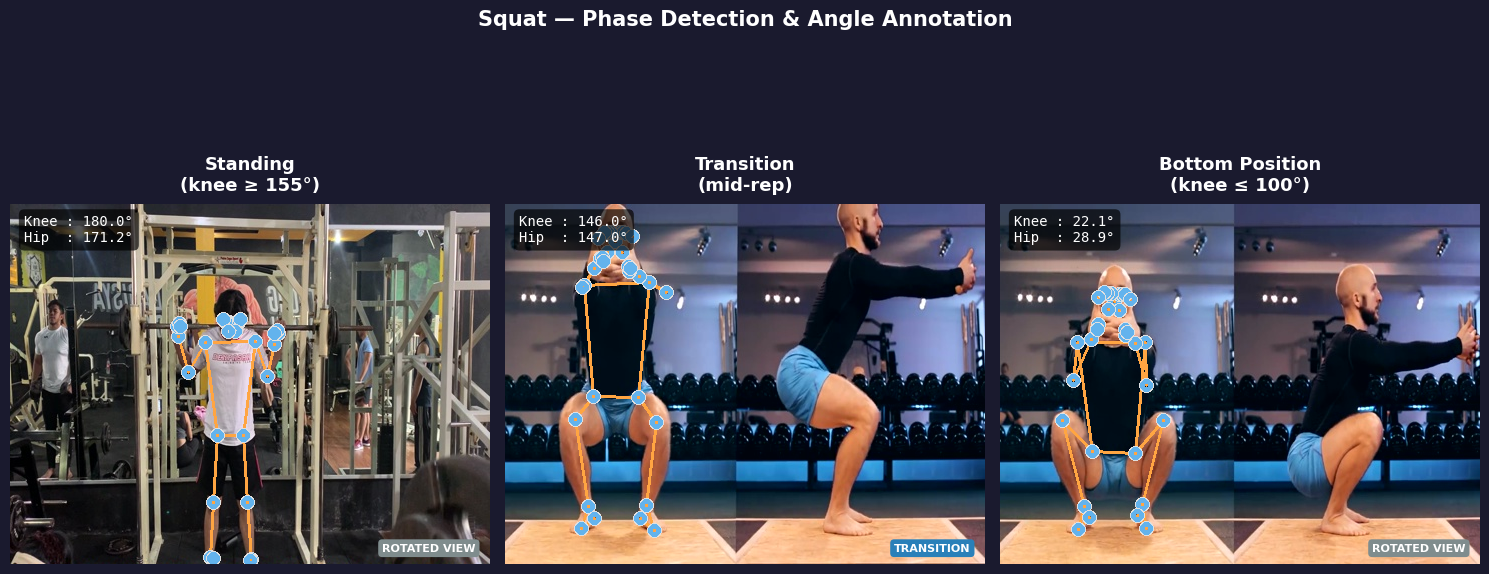

In [18]:
import cv2
import mediapipe as mp
import matplotlib.pyplot as plt
import numpy as np

mp_pose    = mp.solutions.pose
mp_drawing = mp.solutions.drawing_utils

# ── Configure these three filenames ──────────────────────────────────────────
PHASES_DIR = '../data/squat_phases/'

phase_files = {
    'Standing\n(knee ≥ 155°)':        'standing.jpg',
    'Transition\n(mid-rep)':           'transition.jpg',
    'Bottom Position\n(knee ≤ 100°)': 'bottom.jpg',
}

# Angle rows from Cell 1 — already in scope
phase_rows = {
    'Standing\n(knee ≥ 155°)':        standing,
    'Transition\n(mid-rep)':           transition,
    'Bottom Position\n(knee ≤ 100°)': bottom,
}
# ─────────────────────────────────────────────────────────────────────────────

SKELETON_COLOUR = (99,  179, 237)
BONE_COLOUR     = (255, 165,  66)
LABEL_COLOURS   = {
    'correct':      '#27ae60',
    'injury_prone': '#e74c3c',
    'transition':   '#2980b9',
}

def draw_pose(img_bgr):
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    with mp_pose.Pose(static_image_mode=True, min_detection_confidence=0.5) as pose:
        results = pose.process(img_rgb)
    if results.pose_landmarks:
        mp_drawing.draw_landmarks(
            img_rgb, results.pose_landmarks, mp_pose.POSE_CONNECTIONS,
            mp_drawing.DrawingSpec(color=SKELETON_COLOUR, thickness=3, circle_radius=4),
            mp_drawing.DrawingSpec(color=BONE_COLOUR,     thickness=2, circle_radius=2),
        )
    return img_rgb

fig, axes = plt.subplots(1, 3, figsize=(15, 7))
fig.patch.set_facecolor('#1a1a2e')

for ax, (phase_label, filename) in zip(axes, phase_files.items()):
    img_path = PHASES_DIR + filename
    row      = phase_rows[phase_label]

    img = cv2.imread(img_path)
    if img is None:
        ax.text(0.5, 0.5, f'Not found:\n{img_path}',
                ha='center', va='center', color='white',
                fontsize=9, transform=ax.transAxes)
        ax.set_facecolor('#1a1a2e')
        ax.axis('off')
        continue

    ax.imshow(draw_pose(img))
    ax.axis('off')
    ax.set_title(phase_label, color='white', fontsize=13, fontweight='bold', pad=10)

    # Angle badge — top left
    knee = row['knee_num']
    hip  = row['hip_num']
    lines = [f"Knee : {knee:.1f}°" if not np.isnan(knee) else "Knee : —"]
    if not np.isnan(hip):
        lines.append(f"Hip  : {hip:.1f}°")

    ax.text(0.03, 0.97, "\n".join(lines),
            transform=ax.transAxes, va='top', ha='left',
            fontsize=10, family='monospace', color='white',
            bbox=dict(boxstyle='round,pad=0.4',
                      facecolor='#000000aa', edgecolor='none'))

    # Label badge — bottom right
    badge_colour = LABEL_COLOURS.get(row['label'], '#7f8c8d')
    ax.text(0.97, 0.03, row['label'].upper().replace('_', ' '),
            transform=ax.transAxes, va='bottom', ha='right',
            fontsize=8, fontweight='bold', color='white',
            bbox=dict(boxstyle='round,pad=0.35',
                      facecolor=badge_colour, edgecolor='none'))

fig.suptitle('Squat — Phase Detection & Angle Annotation',
             color='white', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../data/squat_phases/squat_phases_annotated.png',
            dpi=150, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()



In [ ]:
image_file = 'image_path_from_csv'  # replace with actual path from the DataFrame
## Setup mediapipe instance
with mp_pose.Pose(static_image_mode=True, min_detection_confidence=0.5, min_tracking_confidence=0.5) as pose:
        # Recolor image to RGB
        image = cv2.imread(image_file)
        image_height, image_width, _ = image.shape
        # Convert the BGR image to RGB before processing.
        results = pose.process(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
        image.flags.writeable = True
        image = cv2.cvtColor(image, cv2.COLOR_RGB2BGR)

        # Extract landmarks
        try:
            landmarks = results.pose_landmarks.landmark
            print(landmarks)
        except:
            pass


        # Render detections
        mp_drawing.draw_landmarks(image, results.pose_landmarks, mp_pose.POSE_CONNECTIONS,
                                mp_drawing.DrawingSpec(color=(245,117,66), thickness=2, circle_radius=2),
                                mp_drawing.DrawingSpec(color=(245,66,230), thickness=2, circle_radius=2)
                                 )

        cv2_imshow(image)